In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import os
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

/home/hansennie/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# 手搓多元线性回归 — 加州房价预测（无正则化）
## 1. 加载数据

In [2]:
# 直接从CSV文件加载加州房价数据
csv_path = 'housing.csv'
df = pd.read_csv(csv_path)

# 删除含有缺失值的行
print(f'原始样本数: {len(df)}')
df = df.dropna()
print(f'清洗后样本数: {len(df)}')

# 创建派生特征 (与 sklearn fetch_california_housing 格式一致)
X = np.column_stack([
    df['median_income'].values,           # MedInc
    df['housing_median_age'].values,      # HouseAge
    df['total_rooms'].values / df['households'].values,   # AveRooms
    df['total_bedrooms'].values / df['households'].values, # AveBedrms
    df['population'].values,              # Population
    df['population'].values / df['households'].values,     # AveOccup
    df['latitude'].values,                # Latitude
    df['longitude'].values,               # Longitude
])

# 目标变量：房价中位数（单位：10万美元）
y = (df['median_house_value'].values / 100000.0).reshape(-1, 1)

feature_names = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                 'Population', 'AveOccup', 'Latitude', 'Longitude']

print(f'数据集大小: {X.shape[0]} 个样本, {X.shape[1]} 个特征')
print(f'特征名: {feature_names}')
print(f'目标变量范围: [{y.min():.4f}, {y.max():.4f}]')
print(f'目标变量均值: {y.mean():.4f}, 标准差: {y.std():.4f}')

原始样本数: 20640
清洗后样本数: 20433
数据集大小: 20433 个样本, 8 个特征
特征名: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
目标变量范围: [0.1500, 5.0000]
目标变量均值: 2.0686, 标准差: 1.1543


## 2. 数据预处理

In [3]:
# 添加偏置项 (截距)
X_with_bias = np.c_[np.ones((X.shape[0], 1)), X]

# 标准化特征（保留偏置列）
scaler = StandardScaler()
X_scaled = X_with_bias.copy()
X_scaled[:, 1:] = scaler.fit_transform(X[:, :])

# 划分训练集与测试集 (8:2)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f'训练集: {X_train.shape[0]}, 测试集: {X_test.shape[0]}')
print(f'特征维度(含偏置): {X_train.shape[1]}')

训练集: 16346, 测试集: 4087
特征维度(含偏置): 9


## 3. 自实现多元线性回归类

In [4]:
class LinearRegression:
    """
    手搓多元线性回归
    支持两种求解方式：
    1. 正规方程 (Normal Equation): theta = (X^T X)^{-1} X^T y
    2. 梯度下降 (Gradient Descent)
    """
    
    def __init__(self, method='normal', lr=0.01, max_iter=1000, tol=1e-6):
        """
        Parameters
        ----------
        method : str, 'normal' 或 'gd'
        lr : float, 梯度下降学习率
        max_iter : int, 梯度下降最大迭代次数
        tol : float, 梯度下降收敛阈值
        """
        self.method = method
        self.lr = lr
        self.max_iter = max_iter
        self.tol = tol
        self.theta = None
        self.cost_history = []
    
    def _cost(self, X, y):
        """均方误差代价函数"""
        m = len(y)
        predictions = X @ self.theta
        return (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    
    def fit_normal(self, X, y):
        """
        正规方程求解
        theta = (X^T X)^{-1} X^T y
        """
        XT_X = X.T @ X
        # 添加小量以保证矩阵可逆
        XT_X_inv = np.linalg.inv(XT_X + 1e-10 * np.eye(XT_X.shape[0]))
        self.theta = XT_X_inv @ X.T @ y
        self.cost_history = [self._cost(X, y)]
        return self
    
    def fit_gd(self, X, y):
        """
        梯度下降求解
        theta = theta - lr * gradient
        梯度: (1/m) * X^T (X@theta - y)
        """
        m, n = X.shape
        self.theta = np.zeros((n, 1))
        self.cost_history = []
        
        for i in range(self.max_iter):
            predictions = X @ self.theta
            gradient = (1 / m) * X.T @ (predictions - y)
            self.theta -= self.lr * gradient
            
            cost = self._cost(X, y)
            self.cost_history.append(cost)
            
            # 检查收敛
            if i > 0 and abs(self.cost_history[-1] - self.cost_history[-2]) < self.tol:
                print(f'梯度下降在第 {i} 轮收敛')
                break
        
        return self
    
    def fit(self, X, y):
        if self.method == 'normal':
            return self.fit_normal(X, y)
        elif self.method == 'gd':
            return self.fit_gd(X, y)
        else:
            raise ValueError(f"Unknown method: {self.method}")
    
    def predict(self, X):
        return X @ self.theta
    
    def score(self, X, y):
        """R^2 决定系数"""
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - ss_res / ss_tot

## 4. 正规方程训练与评估

In [5]:
lr_normal = LinearRegression(method='normal')
lr_normal.fit(X_train, y_train)

y_pred_train = lr_normal.predict(X_train)
y_pred_test = lr_normal.predict(X_test)

print('='*60)
print('正规方程 LinearRegression 结果')
print('='*60)
print(f'权重 theta (含截距):')
print(f'  截距(bias): {lr_normal.theta[0][0]:.4f}')
for i, name in enumerate(feature_names):
    print(f'  {name}: {lr_normal.theta[i+1][0]:.4f}')
print()
print(f'训练集 MSE: {mean_squared_error(y_train, y_pred_train):.6f}')
print(f'测试集 MSE: {mean_squared_error(y_test, y_pred_test):.6f}')
print(f'训练集 RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.6f}')
print(f'测试集 RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.6f}')
print(f'训练集 MAE: {mean_absolute_error(y_train, y_pred_train):.6f}')
print(f'测试集 MAE: {mean_absolute_error(y_test, y_pred_test):.6f}')
print(f'训练集 R^2: {lr_normal.score(X_train, y_train):.4f}')
print(f'测试集 R^2: {lr_normal.score(X_test, y_test):.4f}')

正规方程 LinearRegression 结果
权重 theta (含截距):
  截距(bias): 2.0656
  MedInc: 0.8446
  HouseAge: 0.1207
  AveRooms: -0.3004
  AveBedrms: 0.3706
  Population: -0.0059
  AveOccup: -0.0359
  Latitude: -0.8979
  Longitude: -0.8664

训练集 MSE: 0.516271
测试集 MSE: 0.564592
训练集 RMSE: 0.718520
测试集 RMSE: 0.751394
训练集 MAE: 0.527078
测试集 MAE: 0.540021
训练集 R^2: 0.6100
测试集 R^2: 0.5871


## 5. 梯度下降训练与评估

In [6]:
lr_gd = LinearRegression(method='gd', lr=0.01, max_iter=5000, tol=1e-8)
lr_gd.fit(X_train, y_train)

y_pred_gd_test = lr_gd.predict(X_test)

print('='*60)
print('梯度下降 LinearRegression 结果')
print('='*60)
print(f'迭代次数: {len(lr_gd.cost_history)}')
print(f'测试集 MSE: {mean_squared_error(y_test, y_pred_gd_test):.6f}')
print(f'测试集 R^2: {lr_gd.score(X_test, y_test):.4f}')

梯度下降 LinearRegression 结果
迭代次数: 5000
测试集 MSE: 0.564400
测试集 R^2: 0.5873


## 6. 可视化
### 6.1 梯度下降代价函数收敛曲线

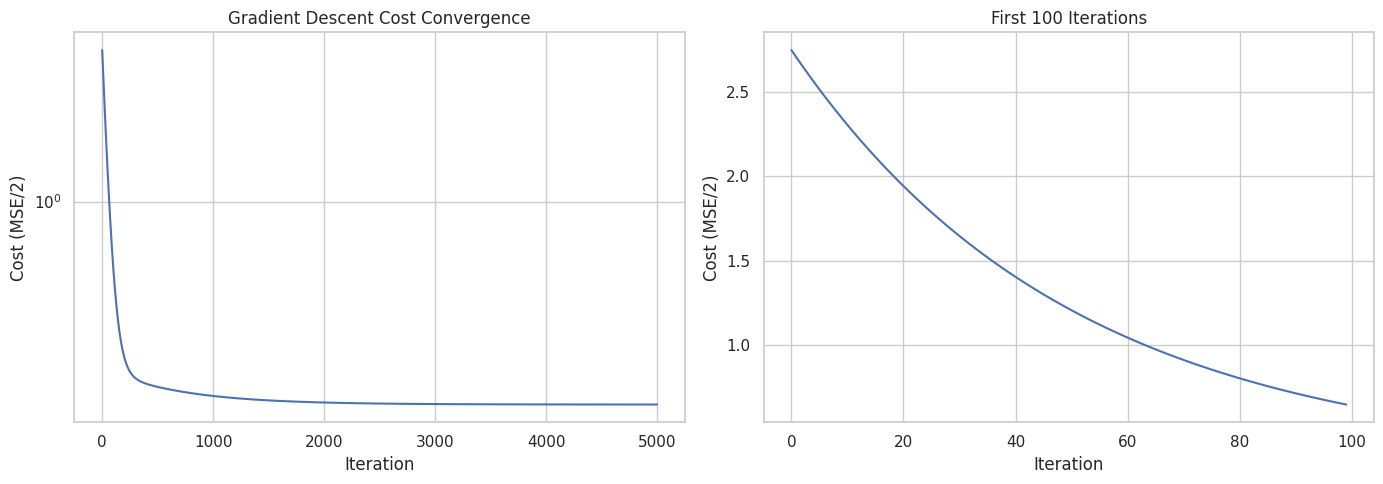

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 代价函数收敛曲线
axes[0].plot(lr_gd.cost_history)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cost (MSE/2)')
axes[0].set_title('Gradient Descent Cost Convergence')
axes[0].set_yscale('log')

# 代价函数前100轮的细节
axes[1].plot(lr_gd.cost_history[:100])
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Cost (MSE/2)')
axes[1].set_title('First 100 Iterations')

plt.tight_layout()
plt.savefig('/tmp/gradient_descent.png', dpi=150)
plt.show()

### 6.2 预测值与真实值对比

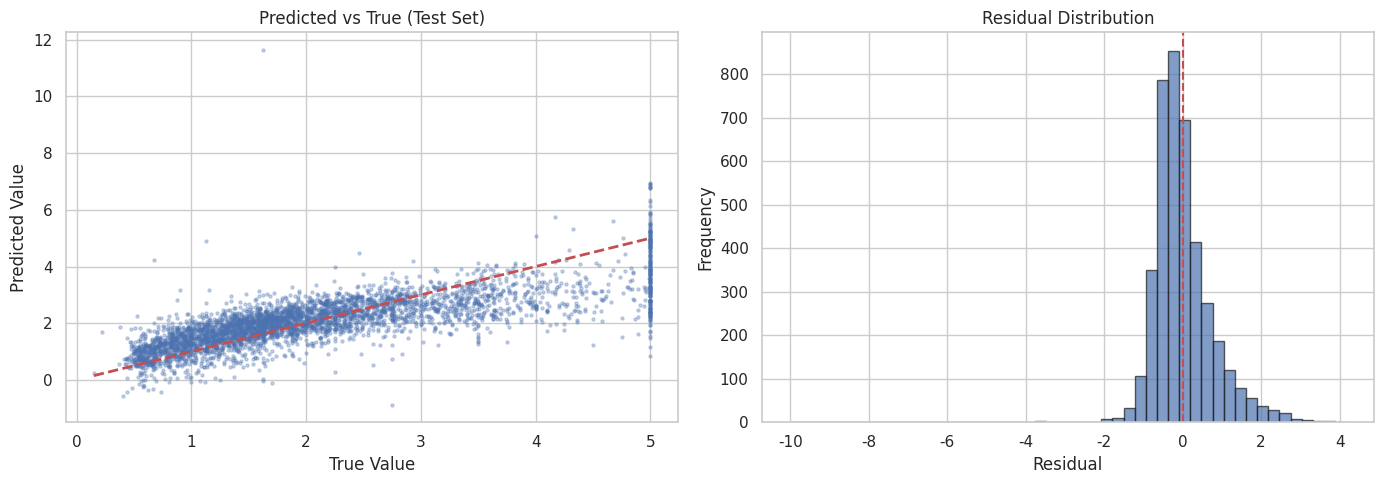

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 散点图
axes[0].scatter(y_test, y_pred_test, alpha=0.3, s=5)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
axes[0].set_xlabel('True Value')
axes[0].set_ylabel('Predicted Value')
axes[0].set_title('Predicted vs True (Test Set)')

# 残差分布
residuals = y_test.flatten() - y_pred_test.flatten()
axes[1].hist(residuals, bins=50, edgecolor='k', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('/tmp/prediction_analysis.png', dpi=150)
plt.show()

### 6.3 特征权重对比

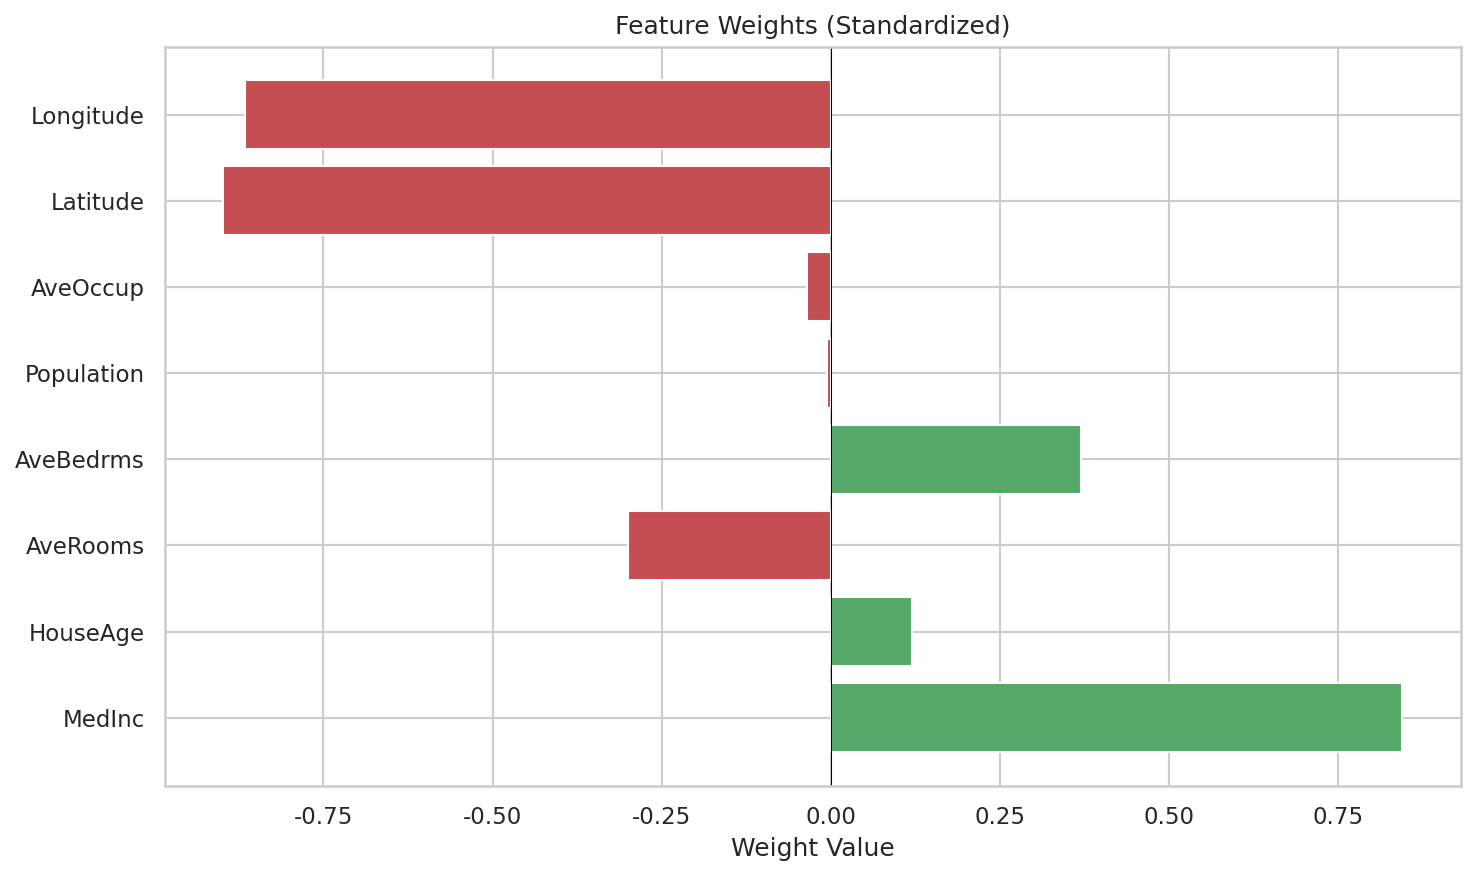

In [9]:
plt.figure(figsize=(10, 6), dpi=150)
weights = lr_normal.theta.flatten()[1:]
colors = ['g' if w > 0 else 'r' for w in weights]
plt.barh(range(len(weights)), weights, color=colors)
plt.yticks(range(len(weights)), feature_names)
plt.xlabel('Weight Value')
plt.title('Feature Weights (Standardized)')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('/tmp/feature_weights.png', dpi=150)
plt.show()

## 7. 与 sklearn 对比验证

In [10]:
from sklearn.linear_model import LinearRegression as SklearnLR

sk_lr = SklearnLR()
sk_lr.fit(X_train[:, 1:], y_train)
sk_pred = sk_lr.predict(X_test[:, 1:])

print('对比结果:')
print(f'  自实现 测试集 R^2: {lr_normal.score(X_test, y_test):.6f}')
print(f'  sklearn 测试集 R^2: {r2_score(y_test, sk_pred):.6f}')
print(f'  自实现 测试集 MSE: {mean_squared_error(y_test, y_pred_test):.6f}')
print(f'  sklearn 测试集 MSE: {mean_squared_error(y_test, sk_pred):.6f}')
print()
print('说明: 自实现正规方程与 sklearn 结果基本一致，验证了算法正确性。')

对比结果:
  自实现 测试集 R^2: 0.587141
  sklearn 测试集 R^2: 0.587141
  自实现 测试集 MSE: 0.564592
  sklearn 测试集 MSE: 0.564592

说明: 自实现正规方程与 sklearn 结果基本一致，验证了算法正确性。
